## **Assignment No -8**

---

**Name** - Wagh Purva Ramesh .
**Roll No** - EN23107132 .
**Batch** - B

---

**Title** - By using multinomial Naive Bayes, RandomForest, Logistic Regression classifiers, perform news
classification and analysis to categorize news articles into predefined categories and extract actionable
insights. Use AG_news dataset.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [69]:
df=pd.read_csv('train.csv')

In [74]:
df

,text,label
0,Wall St. Bears Claw Back Into the Black (Reute...,2
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2
3,Iraq Halts Oil Exports from Main Southern Pipe...,2
4,"Oil prices soar to all-time record, posing new...",2
...,...,...
119995,Pakistan's Musharraf Says Won't Quit as Army C...,0
119996,Renteria signing a top-shelf deal Red Sox gene...,1
119997,Saban not going to Dolphins yet The Miami Dolp...,1
119998,Today's NFL games PITTSBURGH at NY GIANTS Time...,1


In [20]:
df.columns = ['text', 'label']

In [21]:
df.head()

,text,label
0,Wall St. Bears Claw Back Into the Black (Reute...,2
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2
3,Iraq Halts Oil Exports from Main Southern Pipe...,2
4,"Oil prices soar to all-time record, posing new...",2


In [66]:
df.isnull().sum()

np.int64(0)

In [67]:
df =  pd.read_csv('test.csv')

In [68]:
df

,text,label
0,Fears for T N pension after talks Unions repre...,2
1,The Race is On: Second Private Team Sets Launc...,3
2,Ky. Company Wins Grant to Study Peptides (AP) ...,3
3,Prediction Unit Helps Forecast Wildfires (AP) ...,3
4,Calif. Aims to Limit Farm-Related Smog (AP) AP...,3
...,...,...
7595,Around the world Ukrainian presidential candid...,0
7596,Void is filled with Clement With the supply of...,1
7597,Martinez leaves bitter Like Roger Clemens did ...,1
7598,5 of arthritis patients in Singapore take Bext...,2


In [36]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report , confusion_matrix

In [37]:
x = df['text']
y = df['label']

In [38]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [39]:
vectorizer = TfidfVectorizer(stop_words='english', max_features=1000)
x_train_vec = vectorizer.fit_transform(x_train)
x_test_vec = vectorizer.transform(x_test)

1) **Naive Bayes (multinomialNB)** -

In [40]:
model = MultinomialNB()

In [41]:
model.fit(x_train_vec, y_train)

MultinomialNB()

In [42]:
nb_pred = model.predict(x_test_vec)

In [75]:
nb_pred

array([2, 2, 1, ..., 1, 0, 1])

In [43]:
accuracy_nb = accuracy_score(y_test, nb_pred)
print("Naive Bayes Accuracy:", accuracy_nb)

Naive Bayes Accuracy: 0.8536666666666667


In [44]:
classification_report_nb = classification_report(y_test, nb_pred)
print("Naive Bayes Classification Report:\n", classification_report_nb)

Naive Bayes Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.87      0.86      5956
           1       0.90      0.95      0.92      6058
           2       0.82      0.80      0.81      5911
           3       0.84      0.80      0.82      6075

    accuracy                           0.85     24000
   macro avg       0.85      0.85      0.85     24000
weighted avg       0.85      0.85      0.85     24000



In [45]:
cm = confusion_matrix(y_test, nb_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[5159  318  326  153]
 [ 147 5727   96   88]
 [ 335  116 4748  712]
 [ 396  224  601 4854]]


Text(0.5, 1.0, 'Confusion Matrix - Naive Bayes')

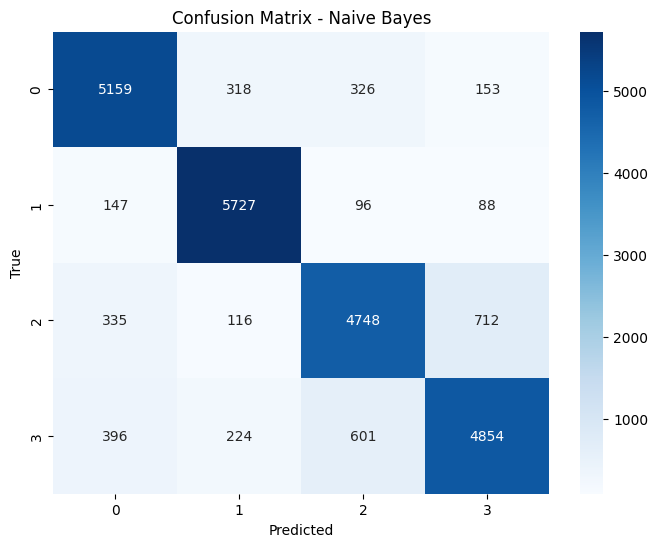

In [48]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Naive Bayes')

2) **Random Forest Classifier** -

In [49]:
model = RandomForestClassifier(n_estimators=100, random_state=42)

In [50]:
model.fit(x_train_vec, y_train)

RandomForestClassifier(random_state=42)

In [51]:
random_pred = model.predict(x_test_vec)

In [76]:
random_pred

array([2, 2, 1, ..., 1, 0, 1])

In [52]:
accuracy_random = accuracy_score(y_test, random_pred)
print("Random forest classifier Accuracy:", accuracy_random)

Random forest classifier Accuracy: 0.8641666666666666


In [53]:
cm = confusion_matrix(y_test, random_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[5187  302  286  181]
 [ 120 5725  116   97]
 [ 315  136 4887  573]
 [ 330  257  547 4941]]


Text(0.5, 1.0, 'Confusion Matrix - Random Forest Classifier')

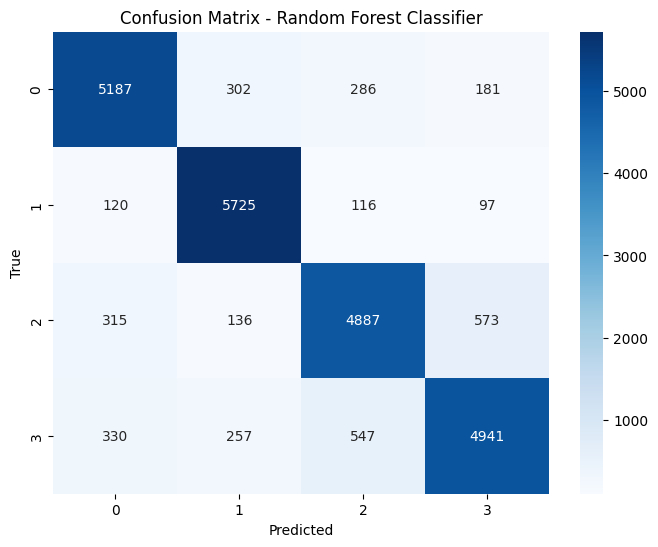

In [54]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Random Forest Classifier')

3) **Logistic Regression classifiers** -

In [55]:
model = LogisticRegression(max_iter=1000)

In [56]:
model.fit(x_train_vec, y_train)

LogisticRegression(max_iter=1000)

In [57]:
logistic_pred = model.predict(x_test_vec)

In [77]:
logistic_pred

array([2, 2, 1, ..., 1, 0, 1])

In [58]:
accuracy_logistic = accuracy_score(y_test, logistic_pred)
print("Logistic Regression Accuracy:", accuracy_logistic)

Logistic Regression Accuracy: 0.8680833333333333


In [59]:
classification_report_logistic = classification_report(y_test, logistic_pred)
print("Logistic Regression Classification Report:\n", classification_report_logistic)

Logistic Regression Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.87      0.87      5956
           1       0.92      0.94      0.93      6058
           2       0.83      0.83      0.83      5911
           3       0.84      0.83      0.83      6075

    accuracy                           0.87     24000
   macro avg       0.87      0.87      0.87     24000
weighted avg       0.87      0.87      0.87     24000



In [60]:
cm = confusion_matrix(y_test, logistic_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[5170  259  321  206]
 [ 135 5721   99  103]
 [ 281   84 4924  622]
 [ 299  168  589 5019]]


Text(0.5, 1.0, 'Confusion Matrix - Logistic Regression')

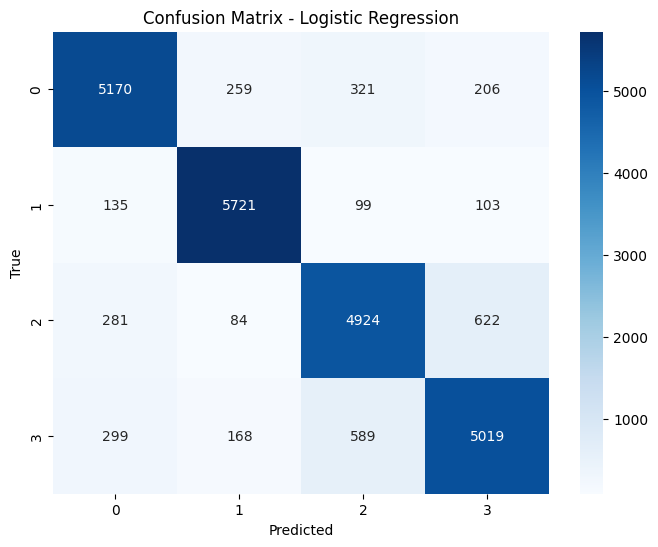

In [61]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Logistic Regression')

 **Model Comparison** -

In [62]:
accuracies = {
    'Naive Bayes': accuracy_nb,
    'Random Forest': accuracy_random,
    'Logistic Regression': accuracy_logistic
}
accuracies_df = pd.DataFrame(accuracies.items(), columns=['Model', 'Accuracy'])
print(accuracies_df)

                 Model  Accuracy
0          Naive Bayes  0.853667
1        Random Forest  0.864167
2  Logistic Regression  0.868083


/tmp/ipython-input-384149276.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=accuracies_df, palette='viridis')


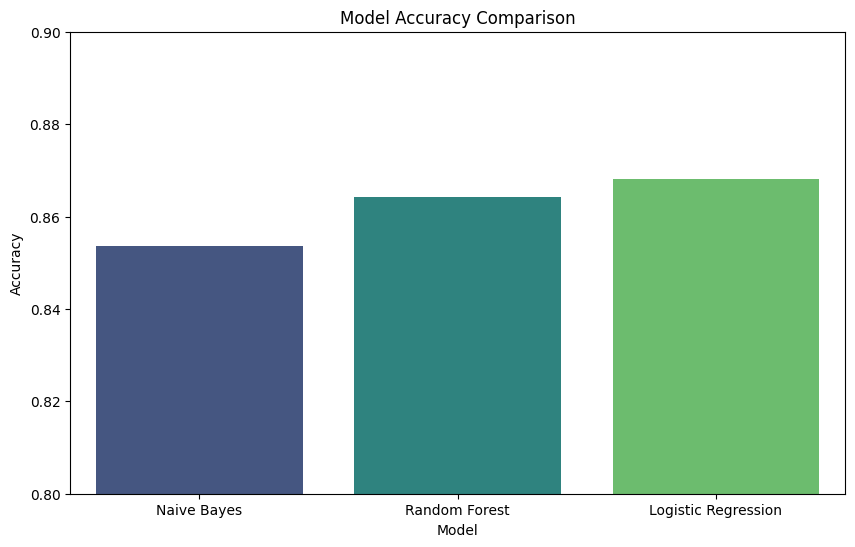

In [63]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Accuracy', data=accuracies_df, palette='viridis')
plt.title('Model Accuracy Comparison')
plt.ylim(0.8, 0.9)
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.show()